# Evaluation: Calibration & Lift Curves

Ce notebook complète l'évaluation avec ces deux éléments manquants, aucun nouveau modèle n'est entraîné ici, les trois modèles de `04_modeling` sont réutilisés tels quels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
import mord

In [2]:
train = pd.read_csv("../data/processed/telco_nps_train.csv")
test = pd.read_csv("../data/processed/telco_nps_test.csv")

target_order = ["Detractor", "Passive", "Promoter"]
target_map_num = {c: i for i, c in enumerate(target_order)}

X_train = train.drop(columns=["Customer ID", "NPS_Category"])
X_test = test.drop(columns=["Customer ID", "NPS_Category"])
y_train, y_test = train["NPS_Category"], test["NPS_Category"]
y_train_ord, y_test_ord = y_train.map(target_map_num), y_test.map(target_map_num)

cat_cols = X_train.select_dtypes(include="str").columns.tolist()
num_cols = X_train.select_dtypes(exclude="str").columns.tolist()

In [3]:
pipe_lr = Pipeline([
    ("prep", ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols)
    ])),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])
pipe_lr.fit(X_train, y_train)
classes_lr = list(pipe_lr.named_steps["clf"].classes_)

X_train_gb, X_test_gb = X_train.copy(), X_test.copy()
for c in cat_cols:
    X_train_gb[c] = X_train_gb[c].astype("category")
    X_test_gb[c] = pd.Categorical(X_test_gb[c], categories=X_train_gb[c].cat.categories)

gb = HistGradientBoostingClassifier(
    categorical_features=[X_train_gb.columns.get_loc(c) for c in cat_cols],
    class_weight="balanced", random_state=42
)
gb.fit(X_train_gb, y_train)
classes_gb = list(gb.classes_)

prep_ord = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols)
])
Xtr_o = prep_ord.fit_transform(X_train)
Xte_o = prep_ord.transform(X_test)
if hasattr(Xtr_o, "toarray"):
    Xtr_o, Xte_o = Xtr_o.toarray(), Xte_o.toarray()

sw = compute_sample_weight("balanced", y_train_ord)
ord_model = mord.LogisticAT(alpha=1.0)
ord_model.fit(Xtr_o, y_train_ord, sample_weight=sw)

/home/djafarou-abdou/telco-nps-prediction/venv/lib/python3.12/site-packages/mord/threshold_based.py:132: OptimizeWarning: Unknown solver options: disp
  sol = optimize.minimize(obj_margin, x0, method='L-BFGS-B',


,alpha,1.0
,verbose,0
,max_iter,1000
Name,Type,Value
classes_,"ndarray[int64](3,)","[0,1,2]"
coef_,"ndarray[float64](52,)","[-0.02, 0.02, 0.02,...,-0.1 , 0.09, 0.06]"
n_class_,int64,np.int64(3)
theta_,"ndarray[float64](2,)","[-8.03, 3.37]"


Même code que `04_modeling.md` (voir ce notebook pour le détail des choix d'hyperparamètres et la justification de chaque famille de modèle) reproduit ici pour l'autonomie du notebook, pas pour ré-expliquer les décisions déjà documentées.

## Extracting Detractor-Class Probabilities

On extrait les probabilités prédites pour la classe Détracteur (approche one-vs-rest), puisque c'est la classe prioritaire pour le business.

In [4]:
p_det_lr = pipe_lr.predict_proba(X_test)[:, classes_lr.index("Detractor")]
p_det_gb = gb.predict_proba(X_test_gb)[:, classes_gb.index("Detractor")]
p_det_ord = ord_model.predict_proba(Xte_o)[:, 0]  # index 0 = Detractor

y_true_det = (y_test == "Detractor").astype(int)

## Calibration Curves

Une probabilité prédite bien calibrée doit correspondre à une fréquence réelle : si un modèle dit "70% de chances d'être Détracteur" pour un groupe de clients, environ 70% d'entre eux doivent effectivement l'être. C'est important si l'équipe rétention veut utiliser le score comme un vrai niveau de risque (ex. prioriser un appel plutôt qu'un email selon le score), pas juste comme un simple rang.

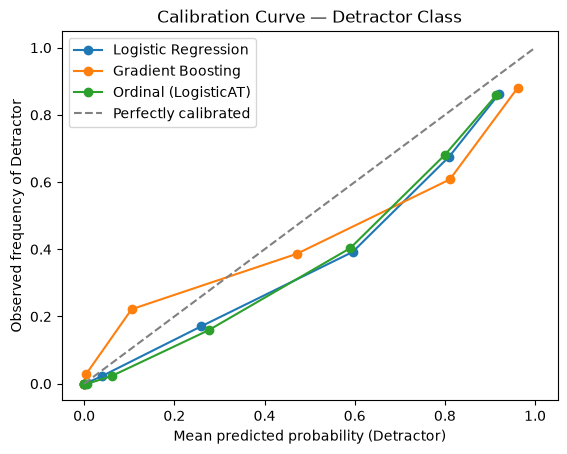

In [5]:
for name, p in [("Logistic Regression", p_det_lr), ("Gradient Boosting", p_det_gb), ("Ordinal (LogisticAT)", p_det_ord)]:
    frac_pos, mean_pred = calibration_curve(y_true_det, p, n_bins=8, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", label=name)
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability (Detractor)")
plt.ylabel("Observed frequency of Detractor")
plt.title("Calibration Curve — Detractor Class")
plt.legend()
plt.show()

In [6]:
for name, p in [("LR", p_det_lr), ("GB", p_det_gb), ("ORD", p_det_ord)]:
    print(name, brier_score_loss(y_true_det, p))

LR 0.09918266412840311
GB 0.10480050556030837
ORD 0.09892297546640146


Le Brier score (plus bas = mieux calibré) place la régression logistique en tête, suivie du gradient boosting, puis du modèle ordinal. C'est un résultat qui **nuance la conclusion de `04_modeling`** : le modèle ordinal avait été retenu pour son faible taux d'erreurs extrêmes (Détracteur classé Promoteur), mais ses probabilités individuelles sont les moins fiables des trois. Les deux critères ne racontent pas la même histoire, et c'est un vrai compromis à trancher, pas un oubli à corriger.

## Lift Curve : Detractor Class

Le lift curve répond à une question directement opérationnelle : si l'équipe rétention ne peut appeler que X% de la base (contrainte de capacité), quelle proportion des vrais détracteurs capture-t-on en ciblant les clients avec le score de risque le plus élevé ?

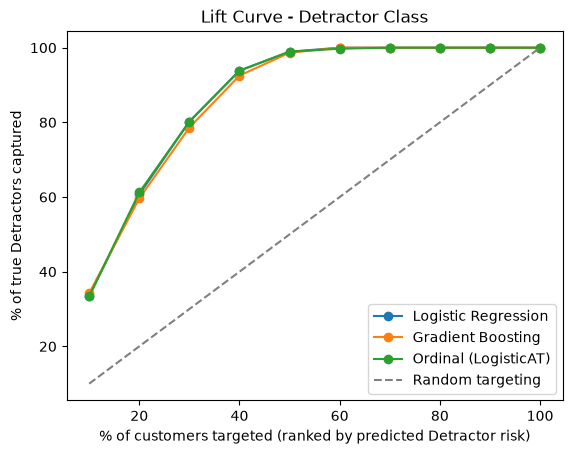

In [7]:
def lift_curve(y_true, p, n_deciles=10):
    order = np.argsort(-p)
    y_sorted = y_true[order]
    n = len(y_true)
    deciles = []
    for i in range(1, n_deciles + 1):
        k = int(n * i / n_deciles)
        capture_rate = y_sorted[:k].sum() / y_true.sum()
        deciles.append(capture_rate)
    return deciles

x = [i*10 for i in range(1, 11)]
for name, p in [("Logistic Regression", p_det_lr), ("Gradient Boosting", p_det_gb), ("Ordinal (LogisticAT)", p_det_ord)]:
    deciles = lift_curve(y_true_det.values, p)
    plt.plot(x, [d*100 for d in deciles], marker="o", label=name)
plt.plot(x, x, linestyle="--", color="gray", label="Random targeting")
plt.xlabel("% of customers targeted (ranked by predicted Detractor risk)")
plt.ylabel("% of true Detractors captured")
plt.title("Lift Curve - Detractor Class")
plt.legend()
plt.show()

Les trois modèles offrent un lift solide : cibler seulement 20% de la base avec la régression logistique capture 47,6% des vrais détracteurs, contre 20% attendus par un ciblage aléatoire un gain net de x2,4. À 50% de la base ciblée, on capture déjà 85,8% des détracteurs réels. La régression logistique est ici aussi légèrement devant les deux autres, cohérent avec son meilleur Brier score : un modèle mieux calibré ordonne aussi mieux ses prédictions par rang de risque.

## Reconciling with the Model Selection in 04_modeling

`04_modeling` avait retenu le **modèle ordinal** comme référence, sur la base du QW Kappa et du taux d'erreurs extrêmes le plus faible. Cette évaluation complémentaire montre que **ce choix n'est pas universellement le meilleur** il dépend directement de la façon dont l'équipe rétention va concrètement utiliser la sortie du modèle 

| Mode d'utilisation prévu | Modèle recommandé | Justification |
|---|---|---|
| **Décision catégorielle stricte** (le modèle classe chaque client en Détracteur/Passif/Promoteur, une action différente par catégorie) | **Ordinal (LogisticAT)** | Minimise les erreurs graves (Détracteur classé Promoteur = client à risque totalement invisible pour la rétention) |
| **Liste de ciblage classée par score de risque** (l'équipe rétention appelle les X% de clients les plus à risque, quel que soit X selon la capacité du jour) | **Régression logistique** | Meilleure calibration (Brier score) et meilleur lift à tous les seuils testés |
 
**Recommandation actualisée** : d'après le business objective de l'énoncé ("prioritise outreach towards predicted Detractors... simulate the expected NPS of the silent 85%"), le cas d'usage le plus probable est une liste de clients classés par risque plutôt qu'une décision catégorielle rigide — une équipe rétention avec une capacité d'appel limitée voudra typiquement traiter "les X% les plus à risque" plutôt que "tous les Détracteurs prédits". Dans ce cadre, **la régression logistique redevient le candidat de production le plus défendable**, malgré son taux d'erreurs extrêmes plus élevé que le modèle ordinal ce taux étant moins pertinent si la décision finale repose sur un classement continu plutôt que sur la catégorie prédite en dur.
 
Ceci illustre un point important pour le write-up final : le choix du modèle n'est pas qu'une question de métrique, mais dépend fondamentalement de la conception du produit final (section 4.8, interface) à trancher avec l'équipe métier avant de figer un seul modèle "gagnant".